In [1]:
import matplotlib.pyplot as plt
import numpy as np

In [2]:
!mkdir -p diagrams/encoder-study/

In [3]:
# ==========================
# Data for K=5
# ==========================
stages = ["Stage-0", "Stage-1"]
encoders = ["Word2Vec", "BERT", "LLAMA-2-7B"]

# NDCG@5 and PopRate@5 values
ndcg5 = {
    "Word2Vec": [0.1087, 0.1602],
    "BERT": [0.1230, 0.1840],
    "LLAMA-2-7B": [0.1863, 0.2071],
}

pr5 = {
    "Word2Vec": [0.4237, 0.3921],
    "BERT": [0.3129, 0.3095],
    "LLAMA-2-7B": [0.3858, 0.3552],
}
DIR_NAME = "diagrams/encoder-study"

In [4]:
# ==========================
# Helper for grouped bar plots (with larger fonts)
# ==========================
def plot_grouped_bars(metric_dict, title, ylabel, filename=None, lower_is_better=False):
    x = np.arange(len(stages))
    width = 0.8 / len(encoders)
    
    fig, ax = plt.subplots(figsize=(9,5))
    colors = ["#4C72B0","#55A868","#C44E52"] # indigo-blue, green, crimson
    
    for i, enc in enumerate(encoders):
        ax.bar(
            x + i*width - (len(encoders)-1)*width/2,
            metric_dict[enc],
            width,
            label=enc,
            color=colors[i]
        )
    
    ax.set_xticks(x)
    ax.set_xticklabels(stages, fontsize=18)          # bigger x-ticks
    ax.set_ylabel(
        ylabel + (" (lower is better)" if lower_is_better else " (higher is better)"),
        fontsize=18
    )
    ax.set_title(title, fontsize=20, fontweight='bold')
    ax.tick_params(axis='y', labelsize=13)            # bigger y-ticks
    
    ax.legend(
        title="Encoder",
        loc="upper right",
        bbox_to_anchor=(1.35, 1),
        fontsize=13,
        title_fontsize=15
    )
    ax.grid(axis="y", linestyle="--", alpha=0.4)

    # Add value labels
    for i, enc in enumerate(encoders):
        xs = x + i*width - (len(encoders)-1)*width/2
        for xi, yi in zip(xs, metric_dict[enc]):
            ax.text(xi, yi, f"{yi:.3f}", ha="center", va="bottom", fontsize=15)
    
    fig.tight_layout()
    if filename:
        fig.savefig(filename, dpi=200, bbox_inches="tight")
    
    plt.show()
    plt.close(fig)
    return

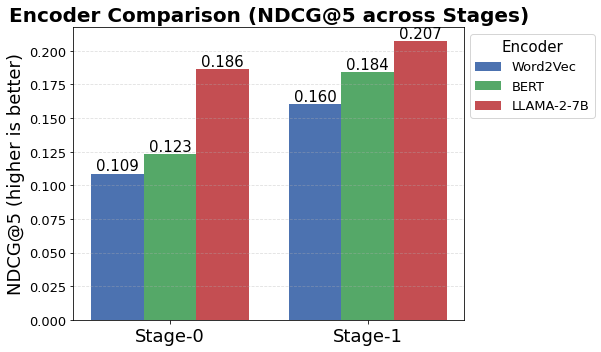

In [5]:
# ==========================
# Generate both plots
# ==========================
plot_grouped_bars(
    ndcg5,
    "Encoder Comparison (NDCG@5 across Stages)",
    "NDCG@5",
    f"{DIR_NAME}/encoders_k5_ndcg5.png"
)

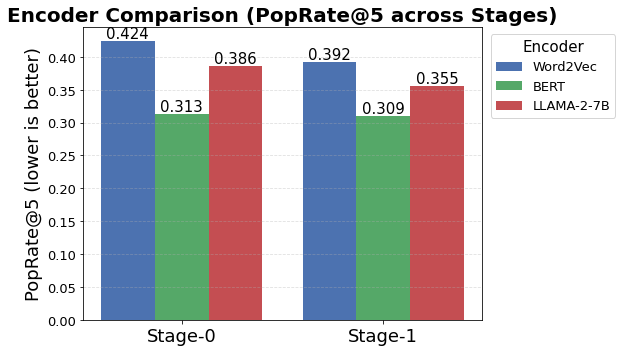

In [6]:


plot_grouped_bars(
    pr5,
    "Encoder Comparison (PopRate@5 across Stages)",
    "PopRate@5",
    f"{DIR_NAME}/encoders_k5_pr5.png",
    lower_is_better=True
)
